# Heart Disease Prediction

Dataset from kaggle - has 302 patient records with medical info like age, cholesterol, blood pressure etc. Target column tells if the person has heart disease or not.

Trying logistic regression and a neural network and comparing which one does better.

## Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_auc_score, roc_curve

import warnings
warnings.filterwarnings('ignore')  # hides unnecessary warnings so output is cleaner

## Load Data

- age, sex (1 = male, 0 = female)
- cp - chest pain type (0 to 3, where 0 = no pain)
- trestbps - resting blood pressure #normal=120/80mmofhg
- chol - cholesterol level
- fbs - fasting blood sugar (1 if above 120, else 0)
- restecg - resting ECG results (0, 1 - ST-T wave abnormality, or 2 - left ventricular hypertrophy (LVH))
- thalach - max heart rate achieved during exercise
- exang - exercise induced chest pain (1 = yes, 0 = no)
- oldpeak - ST depression from exercise vs rest (heart stress indicator)
- slope - slope of the ST segment during exercise
- ca - number of major blood vessels colored by fluoroscopy (0 to 3)
- thal - blood disorder type (1 = normal, 2 = fixed defect, 3 = reversible defect)
- target - 1 = has heart disease, 0 = no disease

In [ ]:
df = pd.read_csv('heart.csv')
print(df.shape)
# print(df.columns)
df.head()

In [ ]:
df.info()

In [ ]:
df['target'].value_counts()

using median to replace invalid values

median is better than mode here because:

(e.g. ca=0 appears 175 times vs others, so mode would always give 0)

median gives the middle value of the distribution, more representative of central tendency

its also robust to skewed distributions unlike mean

In [ ]:
# drop missing if any
before = df.shape[0]
df = df.dropna()
after = df.shape[0]

print("dropped", before - after, "rows")
print("left with", after)

# fix invalid values from UCI dataset
# thal=0 means missing (was '?' in original UCI file), valid values are 1,2,3
# ca=4 is out of range (valid is 0-3), also originally '?' in UCI
print("\nthal=0 (invalid):", (df['thal'] == 0).sum(), "rows")
print("ca=4 (invalid):", (df['ca'] == 4).sum(), "rows")

thal_median = int(df[df['thal'] != 0]['thal'].median())
ca_median = int(df[df['ca'] != 4]['ca'].median())

df.loc[df['thal'] == 0, 'thal'] = thal_median
df.loc[df['ca'] == 4, 'ca'] = ca_median

print(f"\nreplaced thal=0 with median ({thal_median}), ca=4 with median ({ca_median})")
print("final shape:", df.shape)

## EDA

checking basic stats, if the classes are balanced, and how the features correlate with each other

In [ ]:
df.describe()

In [ ]:
df['target'].value_counts().plot(kind='bar')
plt.title('Target Distribution')
plt.xlabel('Target')
plt.ylabel('Count')
plt.savefig('obtained_fig/target_distribution.png', bbox_inches='tight')
plt.show()

1 → perfect positive correlation

0 → no correlation

-1 → perfect negative correlation

In [ ]:
plt.figure(figsize=(10, 8))
corr = df.corr()  # correlation between each pair of columns (-1 to 1)
# annot = show numbers, cmap = color theme, fmt='.1f' = 1 decimal place
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.1f')
plt.title('Correlation Heatmap')
plt.savefig('obtained_fig/correlation_heatmap.png', bbox_inches='tight')
plt.show()

## Preprocessing

splitting into X (features) and y (target)

Dataset is divided into X (features/input variables) and y (target/output variable) so the model can learn to predict y from X.

then 80/20 train test split. using stratify so both sets have same ratio of disease/no disease.

also scaling with StandardScaler (shifts values so mean is 0 and sd is 1) because 

features like cholesterol are in hundreds while sex is just 0 or 1, and

models like LR and neural nets are sensitive to that

In [ ]:
X = df.drop('target', axis=1)  # axis=1 means drop a column not a row
y = df['target']

In [ ]:
# 80-20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # keeps same ratio of disease/no disease in both sets
)

print("train:", X_train.shape[0], "| test:", X_test.shape[0])

scale just means that we are making allthings into same range

In [ ]:
# scale the features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)  # learns the mean/std from train and scales it
X_test_scaled = scaler.transform(X_test)  # uses same mean/std from train to scale test

# before vs after scaling
print("before scaling (first row):", X_train.iloc[0].values)
print()
print("after scaling (first row):", X_train_scaled[0])

## Logistic Regression

its actually a classification model not regression (confusing name). it uses sigmoid to output a probability between 0 and 1.

using GridSearchCV to try different values of C (controls how strict the model is 
- too low = underfits , strong penality, more refularization
- too high = overfits , weaker penalty , freer to fit

and 

penalty (
- l1 = can zero out useless features, it adds |WEIGHT| to loss eg. zeroed our age,chol etc.
- l2 = shrinks all features a bit, adds |WEIGHT|^2 to loss, srinks all to 0 but never fully removes

it picks whichever combo gives the best result. 

cv=5 means it splits training data into 5 parts and tests on each one

In [ ]:
lr_params = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}
# it peaks 0.1 - ie: aggressive feature selection, which is good for small datasets like this (10 features)
# kinda moderate regularizaton , keeping what we need

lr = LogisticRegression(random_state=42) # 42 is just any num, just for reproducibility
lr_grid = GridSearchCV(lr, lr_params, cv=5)
lr_grid.fit(X_train_scaled, y_train)  # tries all combos and picks the best one

best_lr = lr_grid.best_estimator_  # the model with the best params
print("best params:", lr_grid.best_params_)

accuracy - how many predictions were correct overall. 
- CORRECT/TOTAL

precision - of those predicted as disease, how many actually had it.
- TP/(TP+FP)

recall - of those who actually had disease, how many did the model catch.
- TP/(TP +FN)

f1 - balance between precision and recall.
- harmonic mean of precision and recall

auc - how well model separates disease vs no disease (1.0 = perfect, 0.5 = random).

In [ ]:
y_pred_lr = best_lr.predict(X_test_scaled)  # gives 0 or 1
y_pred_lr_proba = best_lr.predict_proba(X_test_scaled)[:, 1] 
# gives the probability (0.0 to 1.0), [:, 1] grabs the disease column

lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr)
lr_recall = recall_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)
lr_auc = roc_auc_score(y_test, y_pred_lr_proba)

print("accuracy:", round(lr_accuracy, 3))
print("precision:", round(lr_precision, 3))
print("recall:", round(lr_recall, 3))
print("f1:", round(lr_f1, 3))
print("auc:", round(lr_auc, 3))
print()
print(classification_report(y_test, y_pred_lr))  # prints all metrics in a nice table

in this above result,
 - support : 28 healthy + 33 disease = 61 -> accurately predicted

confusion matrix - rows are actual, columns are predicted. top-left and bottom-right are correct predictions, the other two are mistakes.

In [ ]:
cm_lr = confusion_matrix(y_test, y_pred_lr)
# annot = show numbers in each box, fmt='d' = whole numbers, cmap = color theme
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues')
plt.title('LR Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig('obtained_fig/lr_confusion_matrix.png', bbox_inches='tight')  # bbox_inches='tight' so nothing gets cut off
plt.show()

In [ ]:
coefs = pd.Series(best_lr.coef_[0], index=X.columns)  # coef_ has the weight for each feature
coefs = coefs.sort_values()

coefs.plot(kind='barh', figsize=(8, 5))
plt.title('Feature Importance (LR Coefficients)')
plt.savefig('obtained_fig/feature_importance.png', bbox_inches='tight')
plt.show()


#  LR coefficients 
# +ve = push prediction towards disease THAT means it affects more
# -ve = pushes prediction towards no disease, decreases log-odds

## ANN

building a simple neural network. 
- first layer has 64 neurons with relu activation <br>
(just means if the value is negative, make it 0), 

- then dropout of 0.3<br>(randomly ignores 30% of neurons so the model doesnt just memorize the training data),<br>
but why?<br>
our datasets tiny, and if not dropped out randomly<br>
it will "learn" that dataset ie OVERFIT and wont work new patients

- then 32 neurons, and output layer with sigmoid <br>
(squishes any number into 0 to 1 range, so it works as a probability).<br>
but why 32?<br>
its enough for 13 feature without memorizing "noise"<br>
0 or 1 is just sigmoid output

using adam optimizer <br>
but why?<br>
(automatically adjusts how fast the model learns - its like default way) and 

<br>
binary_crossentropy as loss function <br>
(measures how wrong the predictions are for yes/no type problems)<br>
its also standard of for binary classification <br>
it heavily penalizes "WRONG PREDICITONS" ex, if model says 0.97 (disease) but the truth is 0 (healthy), loss spikes up

<br>
though MSE would have worked, this way it converegs faster

In [ ]:
model = Sequential()  # layers go one after another

model.add(Dense(64, activation='relu', input_shape=(13,)))  # 64 neurons, relu = zero out negatives
model.add(Dropout(0.3))  # turns off 30% neurons randomly so it doesnt memorize
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='sigmoid'))  # output between 0 and 1

model.compile(
    optimizer='adam',  # handles weight updates
    loss='binary_crossentropy',  # loss for yes/no problems
    metrics=['precision', 'recall', 'accuracy'] #what we want to track during training
)

model.summary()

In [ ]:
history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,  # 20% of train data used to check overfitting
    epochs=50,  # 50 passes through the data
    batch_size=16  # 16 samples at a time
)

train loss = how wrong the model i on data its learning from

val loss = how wrong model is 20% validation part

- 1. if both DOWN, learning well
- 2. if train DOWN, val UP, OVERFITTING
- 3. if both sidewise, not learning

when i tested with 50/50 , though 1 was followed at beginer,
latr it showing overfitting


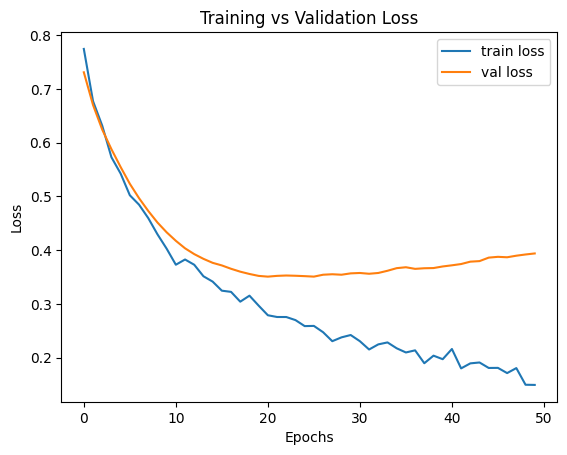

In [120]:
# history stores the loss and accuracy from each epoch
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training vs Validation Loss')
plt.savefig('obtained_fig/training_loss.png', bbox_inches='tight')
plt.show()

In [121]:
y_pred_ann_proba = model.predict(X_test_scaled)  # get predictions from the trained model
y_pred_ann_proba = y_pred_ann_proba.flatten()  # makes it a simple 1D list instead of 2D

y_pred_ann = (y_pred_ann_proba > 0.5).astype(int)  # convert probabilities to 0 or 1

ann_accuracy = accuracy_score(y_test, y_pred_ann)
ann_precision = precision_score(y_test, y_pred_ann)
ann_recall = recall_score(y_test, y_pred_ann)
ann_f1 = f1_score(y_test, y_pred_ann)
ann_auc = roc_auc_score(y_test, y_pred_ann_proba)

print("accuracy:", round(ann_accuracy, 3))
print("precision:", round(ann_precision, 3))
print("recall:", round(ann_recall, 3))
print("f1:", round(ann_f1, 3))
print("auc:", round(ann_auc, 3))
print()
print(classification_report(y_test, y_pred_ann))  # prints all metrics in a nice table

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
accuracy: 0.787
precision: 0.794
recall: 0.818
f1: 0.806
auc: 0.814

              precision    recall  f1-score   support

           0       0.78      0.75      0.76        28
           1       0.79      0.82      0.81        33

    accuracy                           0.79        61
   macro avg       0.79      0.78      0.78        61
weighted avg       0.79      0.79      0.79        61



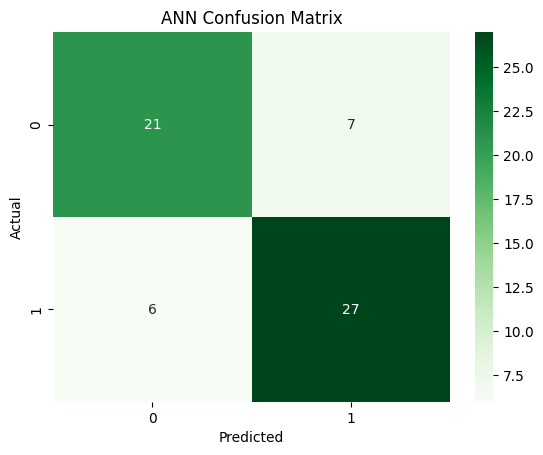

In [122]:
cm_ann = confusion_matrix(y_test, y_pred_ann)
sns.heatmap(cm_ann, annot=True, fmt='d', cmap='Greens')
plt.title('ANN Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig('obtained_fig/ann_confusion_matrix.png', bbox_inches='tight')
plt.show()

## Compare

comparing both models on accuracy, precision, recall, f1 and auc. also plotting roc curves - <br>

basically it shows the tradeoff between catching more disease cases (true positive rate) vs wrongly flagging healthy people (false positive rate). <br>
the more the curve hugs the top-left corner the better

In [123]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Neural Network'],
    'Accuracy': [lr_accuracy, ann_accuracy],
    'Precision': [lr_precision, ann_precision],
    'Recall': [lr_recall, ann_recall],
    'F1': [lr_f1, ann_f1],
    'AUC': [lr_auc, ann_auc]
})

results

,Model,Accuracy,Precision,Recall,F1,AUC
0,Logistic Regression,0.803279,0.800000,0.848485,0.823529,0.891775
1,Neural Network,0.786885,0.794118,0.818182,0.805970,0.813853


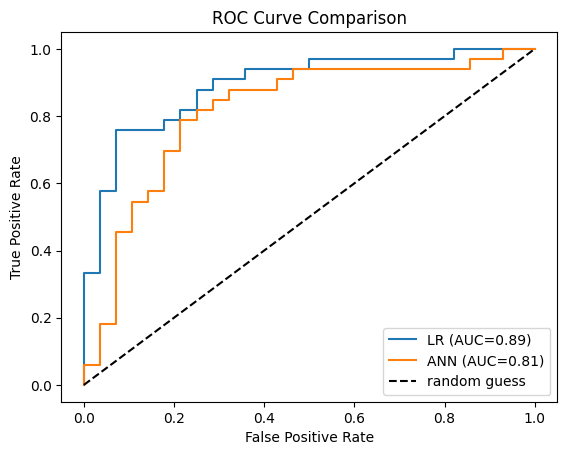

In [124]:
fpr_lr, tpr_lr, thresholds_lr = roc_curve(y_test, y_pred_lr_proba)
fpr_ann, tpr_ann, thresholds_ann = roc_curve(y_test, y_pred_ann_proba)

plt.plot(fpr_lr, tpr_lr, label='LR (AUC=' + str(round(lr_auc, 2)) + ')')
plt.plot(fpr_ann, tpr_ann, label='ANN (AUC=' + str(round(ann_auc, 2)) + ')')
plt.plot([0, 1], [0, 1], color='black', linestyle='--', label='random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.savefig('obtained_fig/roc_curve_comparison.png', bbox_inches='tight')
plt.show()

## Conclusion

both models gave similar results which makes sense because the dataset is pretty small (only 302 rows). logistic regression is nice because the coefficients show which features matter. the neural network didnt really do better here, probably because theres not enough data for it to learn anything extra. with a bigger dataset the ANN might do better